In [1]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import MaNTA

from Objective import make_objective


import jax
import jax.numpy as jnp
import equinox as eqx
import yancc

from yancc_wrapper import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile
import matplotlib.pyplot as plt


Using gpu implementation
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
from Stellarator import StellaratorTransport

fname = "stellarator_opt3"

eq_name = "eq3"

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 400.0,
    "SourceWidth": 0.4,
    "EdgeTemperature":0.2,
    "EdgeDensity": 0.0,
    "n0": 0.25,
}
# runner = MaNTA.Runner(st)

# # %%
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4, 
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.95,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 1e-5,
    "MinStepSize": 1e-8,
    "restart": False,
    "solveAdjoint": True,
    "SteadyStateTolerance": 1e-6,
    
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points =  MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"], solver_config["Grid_size"], solver_config["Polynomial_degree"])
print(points)


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 33

# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired
pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

eq_est = desc.examples.get("ESTELL")
surf = eq_est.get_surface_at(rho=1)

# surf = FourierRZToroidalSurface(
#     R_lmn=[1, 0.166, 0.1],
#     Z_lmn=[-0.166, -0.1],
#     modes_R=[[0, 0], [1, 0], [0, 1]],
#     modes_Z=[[-1, 0], [0, -1]],
#     NFP=2,
# )


eq = Equilibrium(M=8, N=8, Psi=0.1, surface=surf, pressure=desc_pressure)
eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(points, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)

[0.00581204 0.0489505  0.11875    0.1885495  0.23168796 0.24331204
 0.2864505  0.35625    0.4260495  0.46918796 0.48081204 0.5239505
 0.59375    0.6635495  0.70668796 0.71831204 0.7614505  0.83125
 0.9010495  0.94418796]
Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 856
Number of objectives: 5346

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.535e-08
         Total delta_x: 3.111e-01
         Iterations: 33
         Function evaluations: 41
         Jacobian ev

configuring
Successfully created StellaratorTransport object


INFO: Using default value for configuration option Grid_points
INFO: Using default value for configuration option High_Grid_Boundary
INFO: Using default value for configuration option Lower_Boundary_Fraction
INFO: Using default value for configuration option Upper_Boundary_Fraction
INFO: Creating grid with 4 cells from x = 0 to x = 0.95
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option useCalcIC
INFO: Using default value for configuration option WriteOutput
Configuration done.


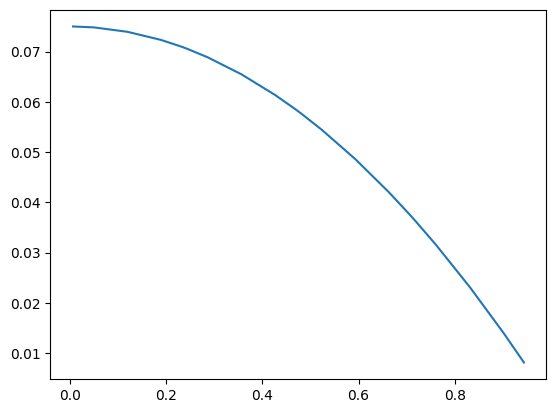

In [3]:


st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)

plt.plot(points, st.InitialValue(0 , points))

In [4]:
st.run()

Setting initial conditions
Residual norm at t = 0: -nan
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 0.0458298


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 44.1202
Residual norm at t = 1e-08: 0
Residual norm at t = 1e-08: 0.403508
Residual norm at t = 2e-08: 0.00373333
Residual norm at t = 4e-08: 0.0308982
Residual norm at t = 4e-08: 0.0321698
Residual norm at t = 8e-08: 0.00270802
Residual norm at t = 8e-08: 0.260759
Residual norm at t = 1.6e-07: 0.00157671
Residual norm at t = 1.6e-07: 0.705035
Residual norm at t = 2.4e-07: 0.00569016
Residual norm at t = 2.4e-07: 0.426801
Residual norm at t = 3.2e-07: 0.0305885
Residual norm at t = 4.8e-07: 0.148131
Residual norm at t = 4.8e-07: 0.371699
Residual norm at t = 6.4e-07: 0.00202218
Residual norm at t = 9.6e-07: 0.119836
Residual norm at t = 9.6e-07: 0.291169
Residual norm at t = 1.28e-06: 0.00516473
Residual norm at t = 1.92e-06: 0.182924
Residual norm at t = 1.92e-06: 0.569741
Residual norm at t = 1.62333e-06: 0.00923253
Residual norm at t = 1.62333e-06: 0.19166
Residual norm at t = 1.96667e-06: 0.00197276
Residual norm at t = 2.65333e-06: 0.158207
Residual norm at

Writing output at 1e-05 ( 20 timesteps )


Residual norm at t = 1e-05: 43.9188


...

Residual norm at t = 0.00036: 30.8679


 dy/dt norm inferred from lambdas is 0.957732
Steady State achieved at time t = 0.00036
Total Number of Timesteps             :41
Total Number of Residual Evaluations  :66
Total Number of Jacobian Computations :15
Computing adjoints


INFO: Computing adjoints for 5720 parameters
Successfully computed dgdp
5720
20


Done.


(Array([0.07637361], dtype=float32),
 Array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

Initializing yancc wrapper
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object


INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option useCalcIC
INFO: Using default value for configuration option WriteOutput
Configuration done.
Setting initial conditions
Residual norm at t = 0: -nan
Residual norm at t = 0: 0
Residual norm at t = 0: -nan
Residual norm at t = 0: 0.0151604


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 6.41487
Residual norm at t = 5e-06: 0
Residual norm at t = 5e-06: 0.322229


Writing output at 5e-06 ( 1 timesteps )


...

Writing output at 5e-06 ( 1 timesteps )


Residual norm at t = 5e-06: 9.75395


 dy/dt norm inferred from lambdas is 0.210967
Steady State achieved at time t = 5e-06
Total Number of Timesteps             :1
Total Number of Residual Evaluations  :5
Total Number of Jacobian Computations :3
Computing adjoints


INFO: Computing adjoints for 5720 parameters
Successfully computed dgdp
5720
20


Done.
[1609.0555  1593.7776  1550.6039  1486.8678  1439.6135  1425.3448
 1369.2136  1266.7599  1150.5887  1073.1106  1051.7576   968.62006
  827.64246  681.20026  588.557    564.33685  471.63992  322.37793
  181.1251   100.69384]
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 104 ms
Timer: Objective build = 121 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 169 ms
Timer: LinearConstraintProjection build = 1.22 sec
Number of parameters: 856
Number of objectives: 5346
Timer: Initializing the optimization = 1.53 sec

Starting optimization
Using method: lsq-exact
Solver options:
---------

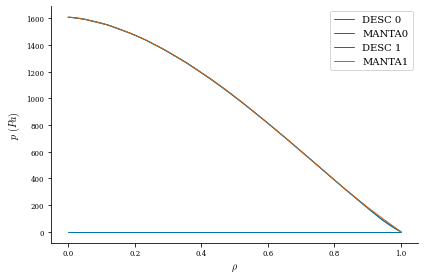

In [5]:
from desc.plotting import plot_1d
from desc.equilibrium import EquilibriaFamily
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.95,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 5e-6,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "SteadyStateTolerance": 1e-7,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

fig, ax = plt.subplots()

eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 2
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta)

    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()
    print(pi)
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)

eq_self_consistent = eq2.copy()

ax.legend()

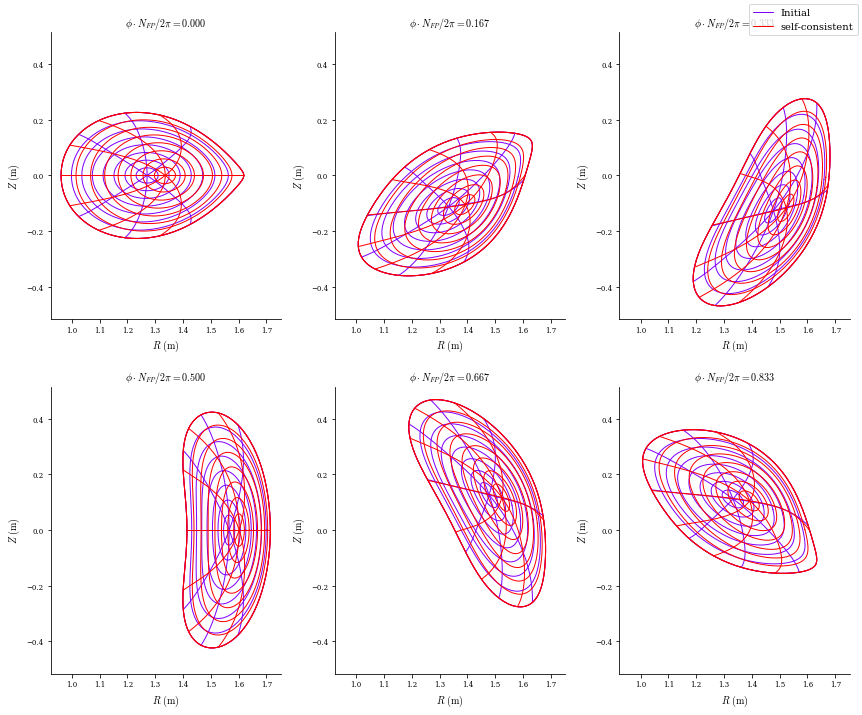

In [6]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq2], labels=["Initial", "self-consistent"]
);

In [7]:
eq = eq2.copy()


In [8]:
import interpax
yancc_wrapper = yancc_data.from_eq(points, eq=eq, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_rho = yancc_wrapper.rho
pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

# grid where desc needs to evaluate field for yancc/manta
yancc_desc_grid = LinearGrid(
    rho=yancc_rho, theta=yancc_ntheta, zeta=yancc_nzeta, NFP=eq.NFP
)


desc_data = eq.compute(["V(r)", "V_r(r)"], grid=yancc_desc_grid)

V = yancc_desc_grid.compress(desc_data['V(r)'])
Vn = V/V[-1] # normalize
Vn = interpax.CubicSpline(yancc_rho, Vn)

rho_from_normalized_volume = lambda Vnorm : desc.backend.root_scalar(lambda x: Vn(x) - Vnorm, jnp.sqrt(Vnorm))    

Initializing yancc wrapper
yancc_wrapper initialized successfully.


In [9]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.95,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 1e-6,
    "MinStepSize": 1e-11,
    "useCalcIC": False,
    "restart": True,
    "solveAdjoint": True, 
    "SteadyStateTolerance": 1e-7,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, vectorized=True)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    Vprime = V_r/V[-1]

    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective(fields, grid, Vprime)

    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")
    
    pressure_error = desc_pressure - manta_pressure

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return jnp.append(pressure_error, 1 / stored_energy)


desc_data = eq.compute(["V(r)", "V_r(r)"], grid=yancc_desc_grid)

V = yancc_desc_grid.compress(desc_data['V(r)'])
Vn = V/V[-1] # normalize
Vn = interpax.CubicSpline(yancc_rho, Vn)

rho_from_normalized_volume = lambda Vnorm : desc.backend.root_scalar(lambda x: Vn(x) - Vnorm, jnp.sqrt(Vnorm))   



# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0
print(domain_boundary_rho)
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()


pressure_constraint_target = jnp.array([0.0, 0.0])
# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

1.0


In [ ]:

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1.0)
stored_energy_weight = 1000.0
objective_from_user_weight = jnp.append(pressure_error_weight, stored_energy_weight)

objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    Volume(eq=eq, target=V0, weight=1.0),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        # need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    # Volume(eq=eq, target=V0), # fix volume of outer flux surface
    # FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)
objective.build(use_jit=False)
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    maxiter=50,
    verbose=3,
    x_scale="ess",
    options={
        "initial_trust_radius": 0.05,
    },
    copy=True,
)

eq_optimized = eq.copy()

Building objective: volume
Precomputing transforms
error when trying to set method compute_scaled
error when trying to set method compute_scaled_error
error when trying to set method compute_unscaled
error when trying to set method compute_scalar
error when trying to set method jac_scaled
error when trying to set method jac_scaled_error
error when trying to set method jac_unscaled
error when trying to set method jvp_scaled
error when trying to set method jvp_scaled_error
error when trying to set method jvp_unscaled
error when trying to set method hess
error when trying to set method grad
Building objective: Custom
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[20])
-------------------------------------------
error when trying to set method compute_scaled
error when

INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option WriteOutput
Configuration done.


Timer: Precomputing transforms = 106 ms
Timer: Objective build = 122 ms
Timer: Objective build = 1.84 ms
Timer: Eq Update LinearConstraintProjection build = 1.28 sec
Timer: Proximal projection build = 7.19 sec
Building objective: fixed current
Building objective: custom linear
Timer: Objective build = 3.77 sec
Timer: LinearConstraintProjection build = 7.60 sec
Number of parameters: 310
Number of objectives: 22
Timer: Initializing the optimization = 19.6 sec

Starting optimization
Using method: proximal-lsq-exact
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object


INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option WriteOutput
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: -nan
Residual norm at t = 0: -nan
Residual norm at t = 0: 0.0158794


Number of Residual Evaluations due to IDACalcIC 3


...

Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 7.52324
Residual norm at t = 1e-06: 0
Residual norm at t = 1e-06: 0.979026


Writing output at 1e-06 ( 1 timesteps )


Residual norm at t = 1e-06: 7.51446


 dy/dt norm inferred from lambdas is 0.307292
Steady State achieved at time t = 1e-06
Total Number of Timesteps             :1
Total Number of Residual Evaluations  :5
Total Number of Jacobian Computations :3
Computing adjoints


In [ ]:
# final self consistency 
fig, ax = plt.subplots()
niters = 2
for k in range(niters):
    eq = eq.copy()

    fig, ax = plot_1d(eq, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta)
 
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq, _ = eq.solve(objective="force", optimizer="lsq-exact", verbose=3)


ax.legend()
eq_optimized_self_consistent = eq.copy()

In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boundaries

plot_comparison(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
plot_boozer_surface(eq, fieldlines=8)
# plot_qs_error(eq_init)
plot_qs_error(eq)